# notes

description:
    Load the FPLC CSV data in FPLC_data/file.csv, clean headers,
    parse numeric columns, and graph signals (UV, Conductivity, Conc B, etc).

requirements:
    pandas, matplotlib

# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# filepath

In [6]:
csvfile = "20260322_ZD_TigE.csv"
# print(f"Current csvfile: {csvfile}")
DATA_DIR = Path(csvfile).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILE = DATA_DIR / csvfile
# print(f"Reading data from: {CSV_FILE}")

# read raw csv


In [12]:
# The file has 2 rows to ignore at the top 
# then one header row, then the data starts at row 4 (0-indexed row 3)
uv_cond_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[0,1,3],  # only mL, mAU, mS/cm columns
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

injection_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[6],  # only injection column
    nrows=1,
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

fractions_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[8,9],  # mL and fraction# 
    engine="python",
    encoding="utf-16",
    # converters={1: int},
    na_values=["", '""'],
)
fractions_raw["Fraction"] = fractions_raw["Fraction"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
# print("Columns:", uv_cond_raw.columns.tolist())

# convert to numeric
uv_cond_df = uv_cond_raw.apply(pd.to_numeric, errors="coerce")
injection_df = injection_raw.apply(pd.to_numeric, errors="coerce")
fractions_df = fractions_raw.apply(pd.to_numeric, errors="coerce")

# print("Data frame shape:", df.shape)
# print("sample data:")
# print(uv_cond_df.head())
# print(injection_df)
# print(fractions_raw)
print(fractions_df.head())

         ml.4  Fraction
0  100.090677       NaN
1  100.543542       2.0
2  102.543489       3.0
3  104.543611       4.0
4  106.544977       5.0


# plot

Saved plot: /Users/zachdinardo/Desktop/School/Penn/BookerLab/BookerLabZD-code/FPLC_data/20260322_ZD_TigE_FPLC_UV_and_cond


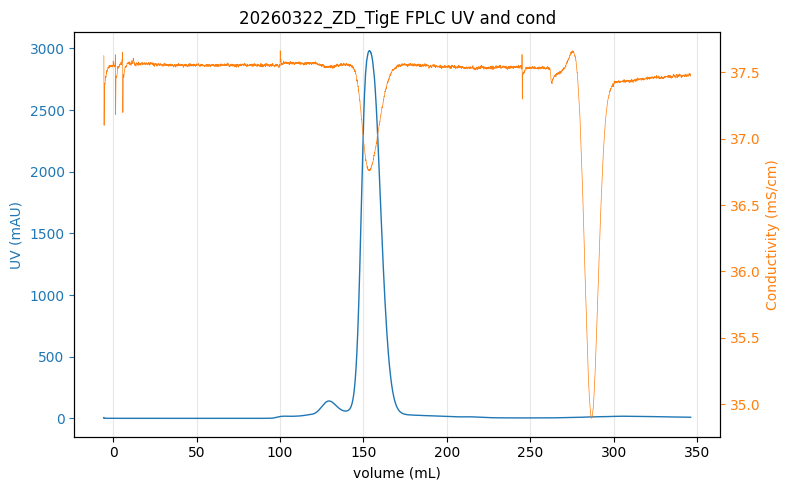

In [9]:
# plot UV (and optionally conductance) vs mL 
show_cond = 1 
x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

fig, ax1 = plt.subplots(figsize=(16*0.5, 10*0.5))

color_uv = "tab:blue"
ax1.set_xlabel("volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

if show_cond == True:
    ax2 = ax1.twinx()
    color_cond = "tab:orange"
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

# Save and show
plt.title(f"{csvfile[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")
ax1.grid(True, axis="x", alpha=0.3)
fig.tight_layout()

out_png = DATA_DIR / f"{csvfile[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}"
fig.savefig(out_png, dpi=1500)
print("Saved plot:", out_png)

plt.show()

Saved plot: /Users/zachdinardo/Desktop/School/Penn/BookerLab/BookerLabZD-code/FPLC_data/20260322_ZD_TigE_FPLC_UV_and_cond_zoomed


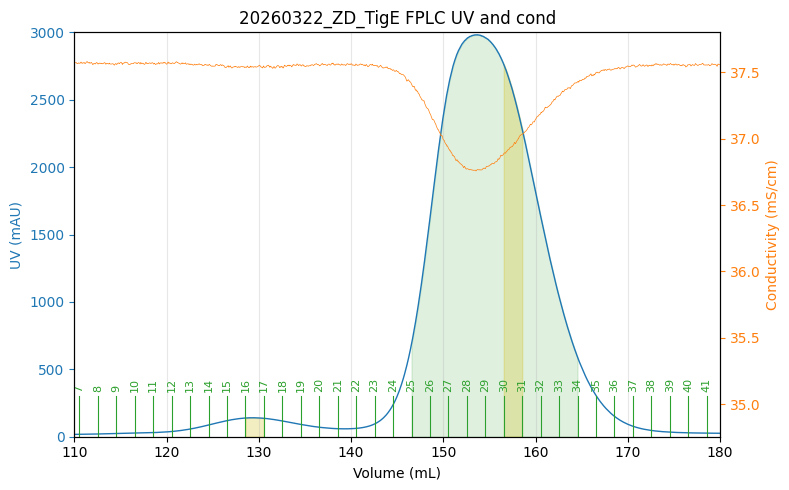

In [30]:
# zoom in on peak of interest with fraction collection 
show_cond = 1
highlight_frac = 1
frac_first = 25
frac_last = 33

gel_samples = [16,30]

ml_start = 110
ml_end = 180
mau_height = 3000

x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

fig, ax1 = plt.subplots(figsize=(16*0.5, 10*0.5))

color_uv = "tab:blue"
color_cond = "tab:orange"
color_frac = "tab:green"
color_gel = "xkcd:mustard yellow"

ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.set_xlim(ml_start,ml_end)
ax1.set_ylim(0,mau_height)
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

if show_cond == True:
    ax2 = ax1.twinx()
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

for i, (ml, frac) in enumerate(zip(fractions_df["ml.4"], fractions_df["Fraction"]), start=1):
    if ml > ml_start and ml < ml_end:
        ax1.axvline(x=ml, color=color_frac, linestyle="-", linewidth=0.8, ymin=0, ymax=0.1)
        ax1.text(ml, ax1.get_ylim()[1]*0.11, f"{frac:.0f}", rotation=90,
                va="bottom", ha="center", fontsize=8, color=color_frac)

# shade the selected fraction range (frac_first..frac_last) under UV curve
if highlight_frac:
    x_min = fractions_df.loc[fractions_df["Fraction"] == frac_first, "ml.4"].iloc[0]
    x_max = fractions_df.loc[fractions_df["Fraction"] == frac_last+1, "ml.4"].iloc[0]
    mask = (x >= x_min) & (x <= x_max)
    ax1.fill_between(x[mask], y_uv[mask], color=color_frac, alpha=0.15)

if len(gel_samples)>0:
    for gel_frac in gel_samples:
        x_min = fractions_df.loc[fractions_df["Fraction"] == gel_frac, "ml.4"].iloc[0]
        x_max = fractions_df.loc[fractions_df["Fraction"] == gel_frac+1, "ml.4"].iloc[0]
        mask = (x >= x_min) & (x <= x_max)
        ax1.fill_between(x[mask], y_uv[mask], color=color_gel, alpha=0.25)

# Save and show
plt.title(f"{csvfile[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")
ax1.grid(True, axis="x", alpha=0.3)
fig.tight_layout()

out_png = DATA_DIR / f"{csvfile[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}_zoomed"
fig.savefig(out_png, dpi=1500)
print("Saved plot:", out_png)

plt.show()